<h1 style="color:magenta;">NSL - Exercises 10 </h1>

### 14/5/2026
### Giulia Federica Bianca Coppi (84486A)

1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, but every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

2. Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the cap_prov_ita.dat file. Do you improve with respect using the same number of computing cores but with independent GA searches?



The objective of this exercise is to parallelize a sequential Genetic Algorithm (GA) using the Message Passing Interface (MPI) library to solve the Traveling Salesman Problem (TSP). In parallel architecture the global computational load is distributed across multiple computing cores.

### Parallel architecture and migration mechanism

In this framework, the optimization process is split into $11$ parallel searches. Each computing core manages an isolated sub-population of $N_{\text{individuals}} = 500$, representing an independent **continent**. To ensure diverse exploration of the search space, each continent is initialized with a unique random seed extracted from the `Primes` file, generating distinct evolutionary trajectories that minimize the risk of simultaneous stagnation in local minima.

To combine independent local exploration with global optimization, a **migration operator** is executed every $N_{\text{migrations}} = 50$ generations, prompting the continents to exchange a block of their $N_{\text{migrants}} = 30$ best-performing individuals. 

The communication protocol is structured as follows to ensure high efficiency and correctness:
1. **Random ring SendRecv:** at each migration event, `rank 0` shuffles the available ranks (cores) to establish a dynamic, random communication ring. This sequence is shared globally via `MPI_Bcast`. Each continent $i$ then transmits its best individuals to continent $i+1$ and receives new ones from continent $i-1$ using `MPI_Sendrecv`. This synchronous call eliminates communication deadlocks
2. **Data linearization:** because chromosomes are stored within custom structured data (`vector<Individual>`), to allow MPI transmission, the top $N_{\text{migrants}}$ chromosomes are flattened into a single-dimensional `vector<int>` of dimension $N_{\text{migrants}} \times N_{\text{city}}$
3. **Fitness re-evaluation:** after receiving the serialized data, each continent reconstructs the individual structures, re-evaluates their fitness via the local cost function, replaces the $N_{\text{migrants}}$ worst individuals of its population with the new immigrants, and re-sorts the population to restore consistency.


### Application to 110 italian cities

The parallel algorithm was applied to optimize the route among the coordinates of 110 Italian provincial capital cities (`cap_prov_ita.dat`). To isolate the statistical impact of the migration operator, two configurations were compared under a strictly constant computational budget (11 cores, 1000 generations, and a total of $11 \times 500 = 5500$ evaluated paths per generation):
* **Independent GA searches:** continents evolve in total isolation with no communication
* **Dependent GA searches:** continents interact via the random ring migration mechanism every 50 generations

The quantitative convergence behavior is illustrated in the plots below, which display the shortest path length ($L^{(1)}$, left) and the population's best-half average length ($\langle L^{(1)} \rangle$, right) as a function of the generation number $N$.

* **Initial phase ($N < 100$):** both curves overlap perfectly. Due to the high selection pressure of the cubic selection operator, the algorithms rapidly exploit the best traits from the initial generation, dominating via local exploration
* **Independent search dynamics (blue):** without communication, the system experiences asymptotic stagnation. Genetic diversity within individual continents is exhausted within 200–300 generations, trapping the nodes in local minima. This leaves sub-optimal path crossings unentangled despite active mutation operators
* **Migration impact (pink):** when migrations are active, the system shows an enhanced optimization capacity
    * the **$L^{(1)}$ plot** displays sharp "steps" or sudden drops right after migration events (e.g., near $N=100$, $450$). "Great immigrants" introduce non-local structural links that disrupt local stagnation and instantly lower the best cost
    * The **$\langle L^{(1)} \rangle$ plot** shows that the pink curve stays systematically lower than the blue one after generation 100. This proves that migrations structurally elevate the fitness of the entire sub-population rather than just injecting a single lucky path.

At the end of the 1000 generations, the model with active migrations achieves a lower final cost in both metrics. Since the total number of evaluated individuals is identical in both simulations, I can conclude that interacting parallel nodes via structured migration provides a major statistical advantage, significantly outperforming independent parallel searches in both convergence speed and final path minimization.

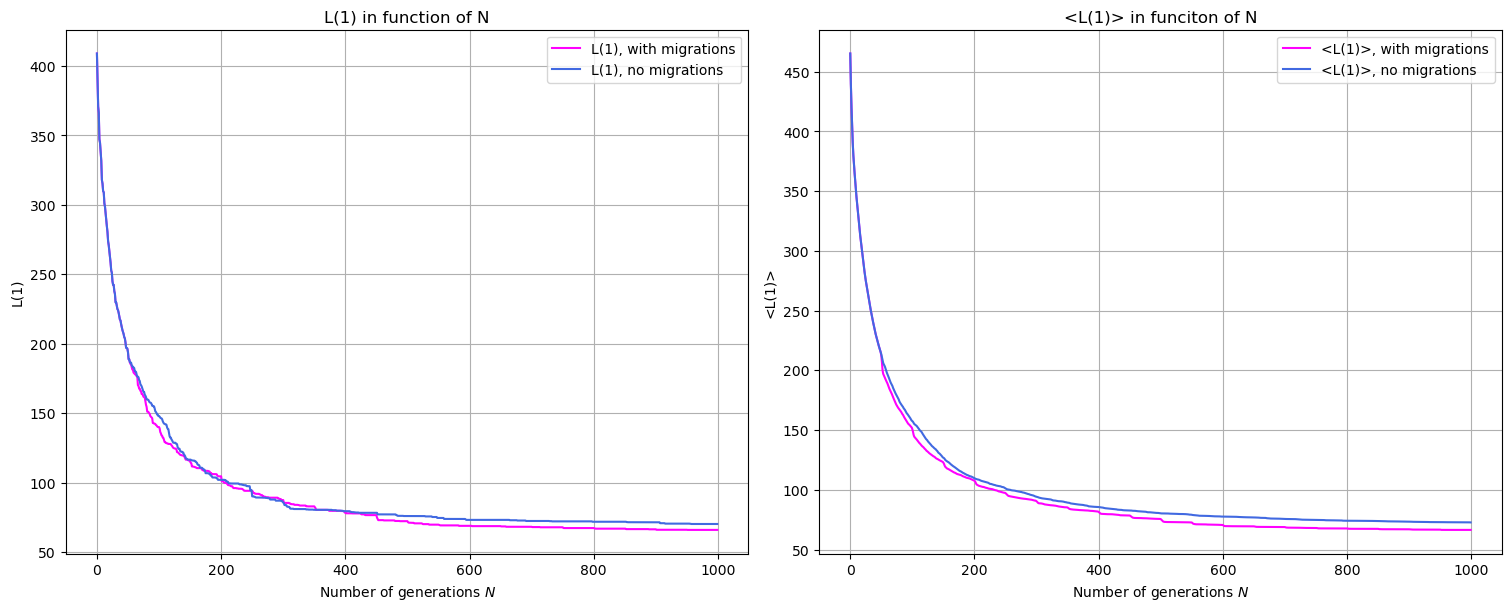

In [11]:
import matplotlib.pyplot as plt
import numpy as np

circle_L = np.loadtxt("./Ex/with_migrations/L_global_best.dat")
circle_L_mean = np.loadtxt("./Ex/with_migrations/L_mean_global_best.dat")

x_circle = circle_L[:, 0]
y_circle = circle_L[:, 1]
x_circle_mean = circle_L_mean[:, 0]
y_circle_mean = circle_L_mean[:, 1]

no_L = np.loadtxt("./Ex/no_migrations/L_global_best.dat")
no_L_mean = np.loadtxt("./Ex/no_migrations/L_mean_global_best.dat")

x_no = no_L[:, 0]
y_no = no_L[:, 1]
x_no_mean = no_L_mean[:, 0]
y_no_mean = no_L_mean[:, 1]




fig, ax = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

ax[0].plot(x_circle, y_circle, color='magenta', label='L(1), with migrations')
ax[0].plot(x_no, y_no, color='royalblue', label='L(1), no migrations')
ax[0].set_title("L(1) in function of N")
ax[0].set_xlabel("Number of generations $N$")
ax[0].set_ylabel("L(1)")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_circle_mean, y_circle_mean, color='magenta', label='<L(1)>, with migrations')
ax[1].plot(x_no_mean, y_no_mean, color='royalblue', label='<L(1)>, no migrations')
ax[1].set_title("<L(1)> in funciton of N")
ax[1].set_xlabel("Number of generations $N$")
ax[1].set_ylabel("<L(1)>")
ax[1].legend()
ax[1].grid(True)


plt.show()


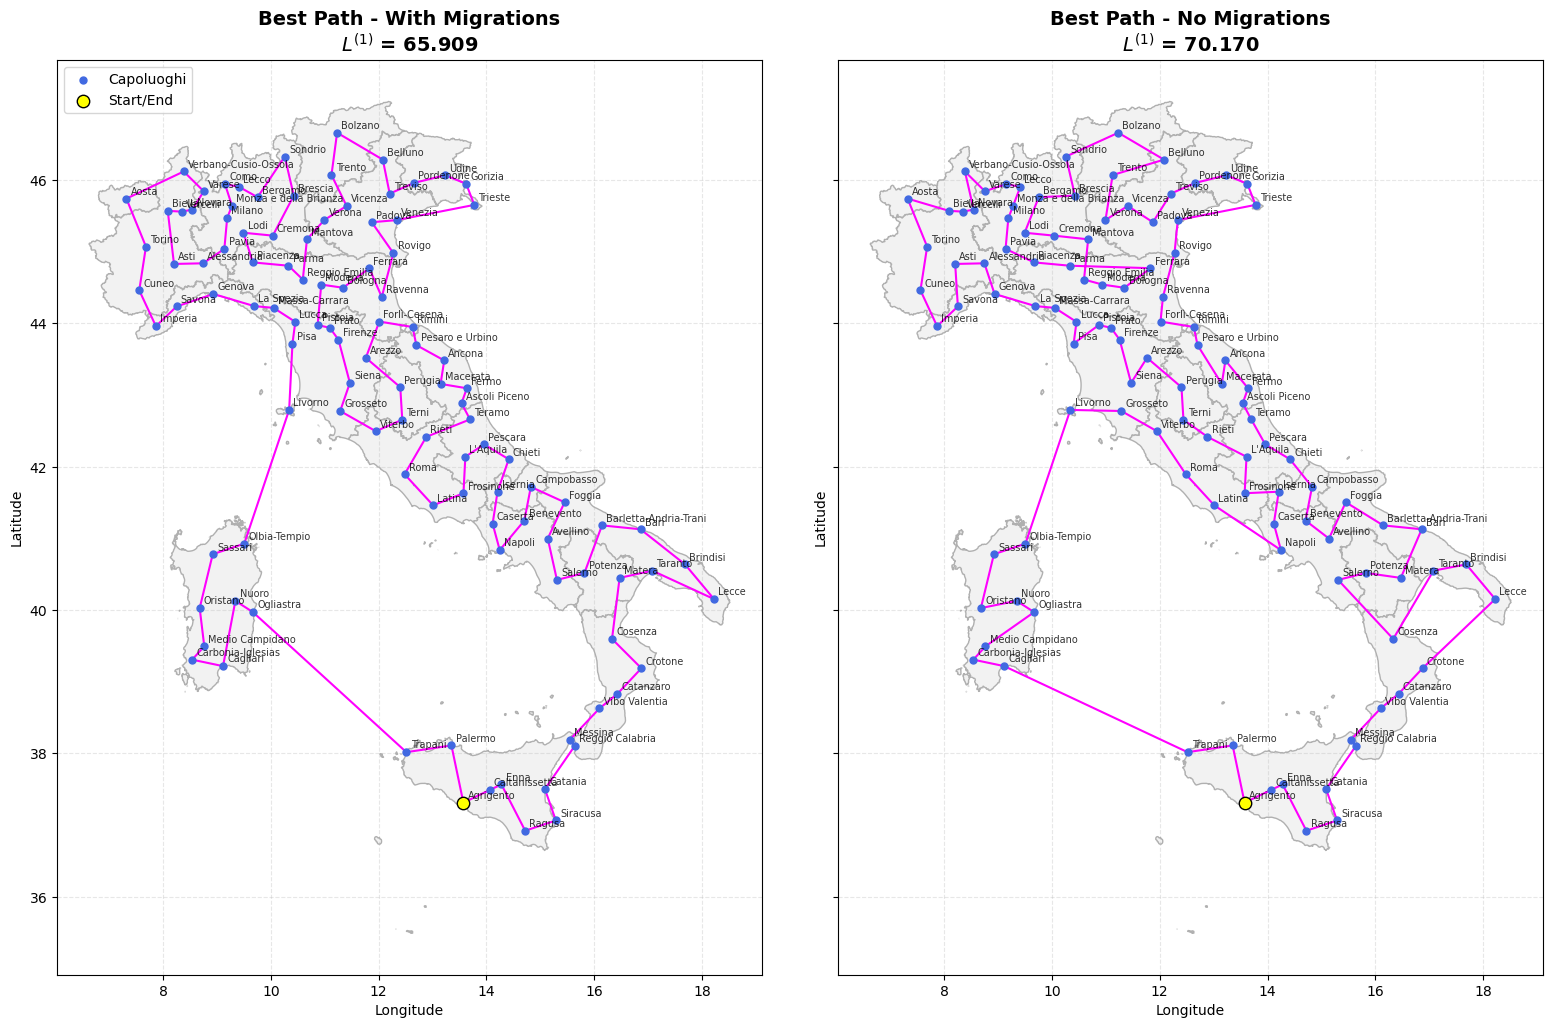

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

italy = gpd.read_file("italia.geojson")

coordinates = np.loadtxt("Ex/cap_prov_ita.dat")
x_city, y_city = coordinates[:, 0], coordinates[:, 1]

with open("Ex/prov_ita.txt", "r") as f:
    city_names = [line.strip() for line in f.readlines() if line.strip()]

route_mig = np.loadtxt("Ex/with_migrations/best_route.dat", dtype=int) - 1
best_cost_mig = np.loadtxt("Ex/with_migrations/L_global_best.dat")[-1, 1]

route_no_mig = np.loadtxt("Ex/no_migrations/best_route.dat", dtype=int) - 1
best_cost_no_mig = np.loadtxt("Ex/no_migrations/L_global_best.dat")[-1, 1]

route_mig = np.append(route_mig, route_mig[0])
route_no_mig = np.append(route_no_mig, route_no_mig[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10), sharex=True, sharey=True)

# 1. WITH MIGRATIONS
ax1.set_title(f"Best Path - With Migrations\n$L^{{(1)}}$ = {best_cost_mig:.3f}", fontsize=14, fontweight='bold')
italy.plot(ax=ax1, facecolor='#f2f2f2', edgecolor='#b0b0b0', zorder=1)
ax1.scatter(x_city, y_city, color='royalblue', s=25, zorder=3, label="Capoluoghi")
ax1.plot(x_city[route_mig], y_city[route_mig], color='magenta', linewidth=1.5, zorder=2)
ax1.scatter(x_city[route_mig[0]], y_city[route_mig[0]], color='yellow', s=80, edgecolors='black', zorder=5, label="Start/End")

for i, name in enumerate(city_names):
    ax1.annotate(name, (x_city[i], y_city[i]), fontsize=7, alpha=0.8, xytext=(3,3), textcoords="offset points", zorder=4)

ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.legend(loc="upper left")

# 2. NO MIGRATIONS
ax2.set_title(f"Best Path - No Migrations\n$L^{{(1)}}$ = {best_cost_no_mig:.3f}", fontsize=14, fontweight='bold')
italy.plot(ax=ax2, facecolor='#f2f2f2', edgecolor='#b0b0b0', zorder=1)
ax2.scatter(x_city, y_city, color='royalblue', s=25, zorder=3)
ax2.plot(x_city[route_no_mig], y_city[route_no_mig], color='magenta', linewidth=1.5, zorder=2)
ax2.scatter(x_city[route_no_mig[0]], y_city[route_no_mig[0]], color='yellow', s=80, edgecolors='black', zorder=5)

for i, name in enumerate(city_names):
    ax2.annotate(name, (x_city[i], y_city[i]), fontsize=7, alpha=0.8, xytext=(3,3), textcoords="offset points", zorder=4)

ax2.grid(True, linestyle='--', alpha=0.3)
ax2.set_ylabel("Latitude")
ax2.set_xlabel("Longitude")

plt.tight_layout()
plt.show()